<a href="https://colab.research.google.com/github/PalakTolwani/Datascience/blob/main/Model_building.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve, precision_score, ConfusionMatrixDisplay,mean_squared_error

In [ ]:
df = pd.read_csv(r'/content/sample_data/california_housing_test.csv')
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0
...,...,...,...,...,...,...,...,...,...
2995,-119.86,34.42,23.0,1450.0,642.0,1258.0,607.0,1.1790,225000.0
2996,-118.14,34.06,27.0,5257.0,1082.0,3496.0,1036.0,3.3906,237200.0
2997,-119.70,36.30,10.0,956.0,201.0,693.0,220.0,2.2895,62000.0
2998,-117.12,34.10,40.0,96.0,14.0,46.0,14.0,3.2708,162500.0


In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0


In [ ]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
2995,-119.86,34.42,23.0,1450.0,642.0,1258.0,607.0,1.1790,225000.0
2996,-118.14,34.06,27.0,5257.0,1082.0,3496.0,1036.0,3.3906,237200.0
2997,-119.70,36.30,10.0,956.0,201.0,693.0,220.0,2.2895,62000.0
2998,-117.12,34.10,40.0,96.0,14.0,46.0,14.0,3.2708,162500.0
2999,-119.63,34.42,42.0,1765.0,263.0,753.0,260.0,8.5608,500001.0


In [ ]:
df.isna()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
2995,False,False,False,False,False,False,False,False,False
2996,False,False,False,False,False,False,False,False,False
2997,False,False,False,False,False,False,False,False,False
2998,False,False,False,False,False,False,False,False,False


In [ ]:
df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


In [ ]:
df.columns[df.isna().mean()>0]

Index([], dtype='object')

In [ ]:
col_to_drop= df.columns[df.isna().mean()>0.3]
col_to_drop

Index([], dtype='object')

In [ ]:
df.drop(col_to_drop, axis = 1)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0
...,...,...,...,...,...,...,...,...,...
2995,-119.86,34.42,23.0,1450.0,642.0,1258.0,607.0,1.1790,225000.0
2996,-118.14,34.06,27.0,5257.0,1082.0,3496.0,1036.0,3.3906,237200.0
2997,-119.70,36.30,10.0,956.0,201.0,693.0,220.0,2.2895,62000.0
2998,-117.12,34.10,40.0,96.0,14.0,46.0,14.0,3.2708,162500.0


In [ ]:
df.abs()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0
...,...,...,...,...,...,...,...,...,...
2995,119.86,34.42,23.0,1450.0,642.0,1258.0,607.0,1.1790,225000.0
2996,118.14,34.06,27.0,5257.0,1082.0,3496.0,1036.0,3.3906,237200.0
2997,119.70,36.30,10.0,956.0,201.0,693.0,220.0,2.2895,62000.0
2998,117.12,34.10,40.0,96.0,14.0,46.0,14.0,3.2708,162500.0


In [ ]:
fill_value =df['longitude'].mean()

In [ ]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.00000
mean,-119.589200,35.63539,28.845333,2599.578667,529.950667,1402.798667,489.91200,3.807272,205846.27500
std,1.994936,2.12967,12.555396,2155.593332,415.654368,1030.543012,365.42271,1.854512,113119.68747
min,-124.180000,32.56000,1.000000,6.000000,2.000000,5.000000,2.00000,0.499900,22500.00000
25%,-121.810000,33.93000,18.000000,1401.000000,291.000000,780.000000,273.00000,2.544000,121200.00000
50%,-118.485000,34.27000,29.000000,2106.000000,437.000000,1155.000000,409.50000,3.487150,177650.00000
75%,-118.020000,37.69000,37.000000,3129.000000,636.000000,1742.750000,597.25000,4.656475,263975.00000
max,-114.490000,41.92000,52.000000,30450.000000,5419.000000,11935.000000,4930.00000,15.000100,500001.00000


In [ ]:
imputer = SimpleImputer(strategy= 'mean')
imput = imputer.fit_transform(df)
imput

array([[-1.22050e+02,  3.73700e+01,  2.70000e+01, ...,  6.06000e+02,
         6.60850e+00,  3.44700e+05],
       [-1.18300e+02,  3.42600e+01,  4.30000e+01, ...,  2.77000e+02,
         3.59900e+00,  1.76500e+05],
       [-1.17810e+02,  3.37800e+01,  2.70000e+01, ...,  4.95000e+02,
         5.79340e+00,  2.70500e+05],
       ...,
       [-1.19700e+02,  3.63000e+01,  1.00000e+01, ...,  2.20000e+02,
         2.28950e+00,  6.20000e+04],
       [-1.17120e+02,  3.41000e+01,  4.00000e+01, ...,  1.40000e+01,
         3.27080e+00,  1.62500e+05],
       [-1.19630e+02,  3.44200e+01,  4.20000e+01, ...,  2.60000e+02,
         8.56080e+00,  5.00001e+05]])

In [ ]:
df = pd.DataFrame(imput, columns=df.columns)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0
...,...,...,...,...,...,...,...,...,...
2995,-119.86,34.42,23.0,1450.0,642.0,1258.0,607.0,1.1790,225000.0
2996,-118.14,34.06,27.0,5257.0,1082.0,3496.0,1036.0,3.3906,237200.0
2997,-119.70,36.30,10.0,956.0,201.0,693.0,220.0,2.2895,62000.0
2998,-117.12,34.10,40.0,96.0,14.0,46.0,14.0,3.2708,162500.0


In [ ]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.00000
mean,-119.589200,35.63539,28.845333,2599.578667,529.950667,1402.798667,489.91200,3.807272,205846.27500
std,1.994936,2.12967,12.555396,2155.593332,415.654368,1030.543012,365.42271,1.854512,113119.68747
min,-124.180000,32.56000,1.000000,6.000000,2.000000,5.000000,2.00000,0.499900,22500.00000
25%,-121.810000,33.93000,18.000000,1401.000000,291.000000,780.000000,273.00000,2.544000,121200.00000
50%,-118.485000,34.27000,29.000000,2106.000000,437.000000,1155.000000,409.50000,3.487150,177650.00000
75%,-118.020000,37.69000,37.000000,3129.000000,636.000000,1742.750000,597.25000,4.656475,263975.00000
max,-114.490000,41.92000,52.000000,30450.000000,5419.000000,11935.000000,4930.00000,15.000100,500001.00000


In [ ]:
df.isna().mean()

,0
longitude,0.0
latitude,0.0
housing_median_age,0.0
total_rooms,0.0
total_bedrooms,0.0
population,0.0
households,0.0
median_income,0.0
median_house_value,0.0


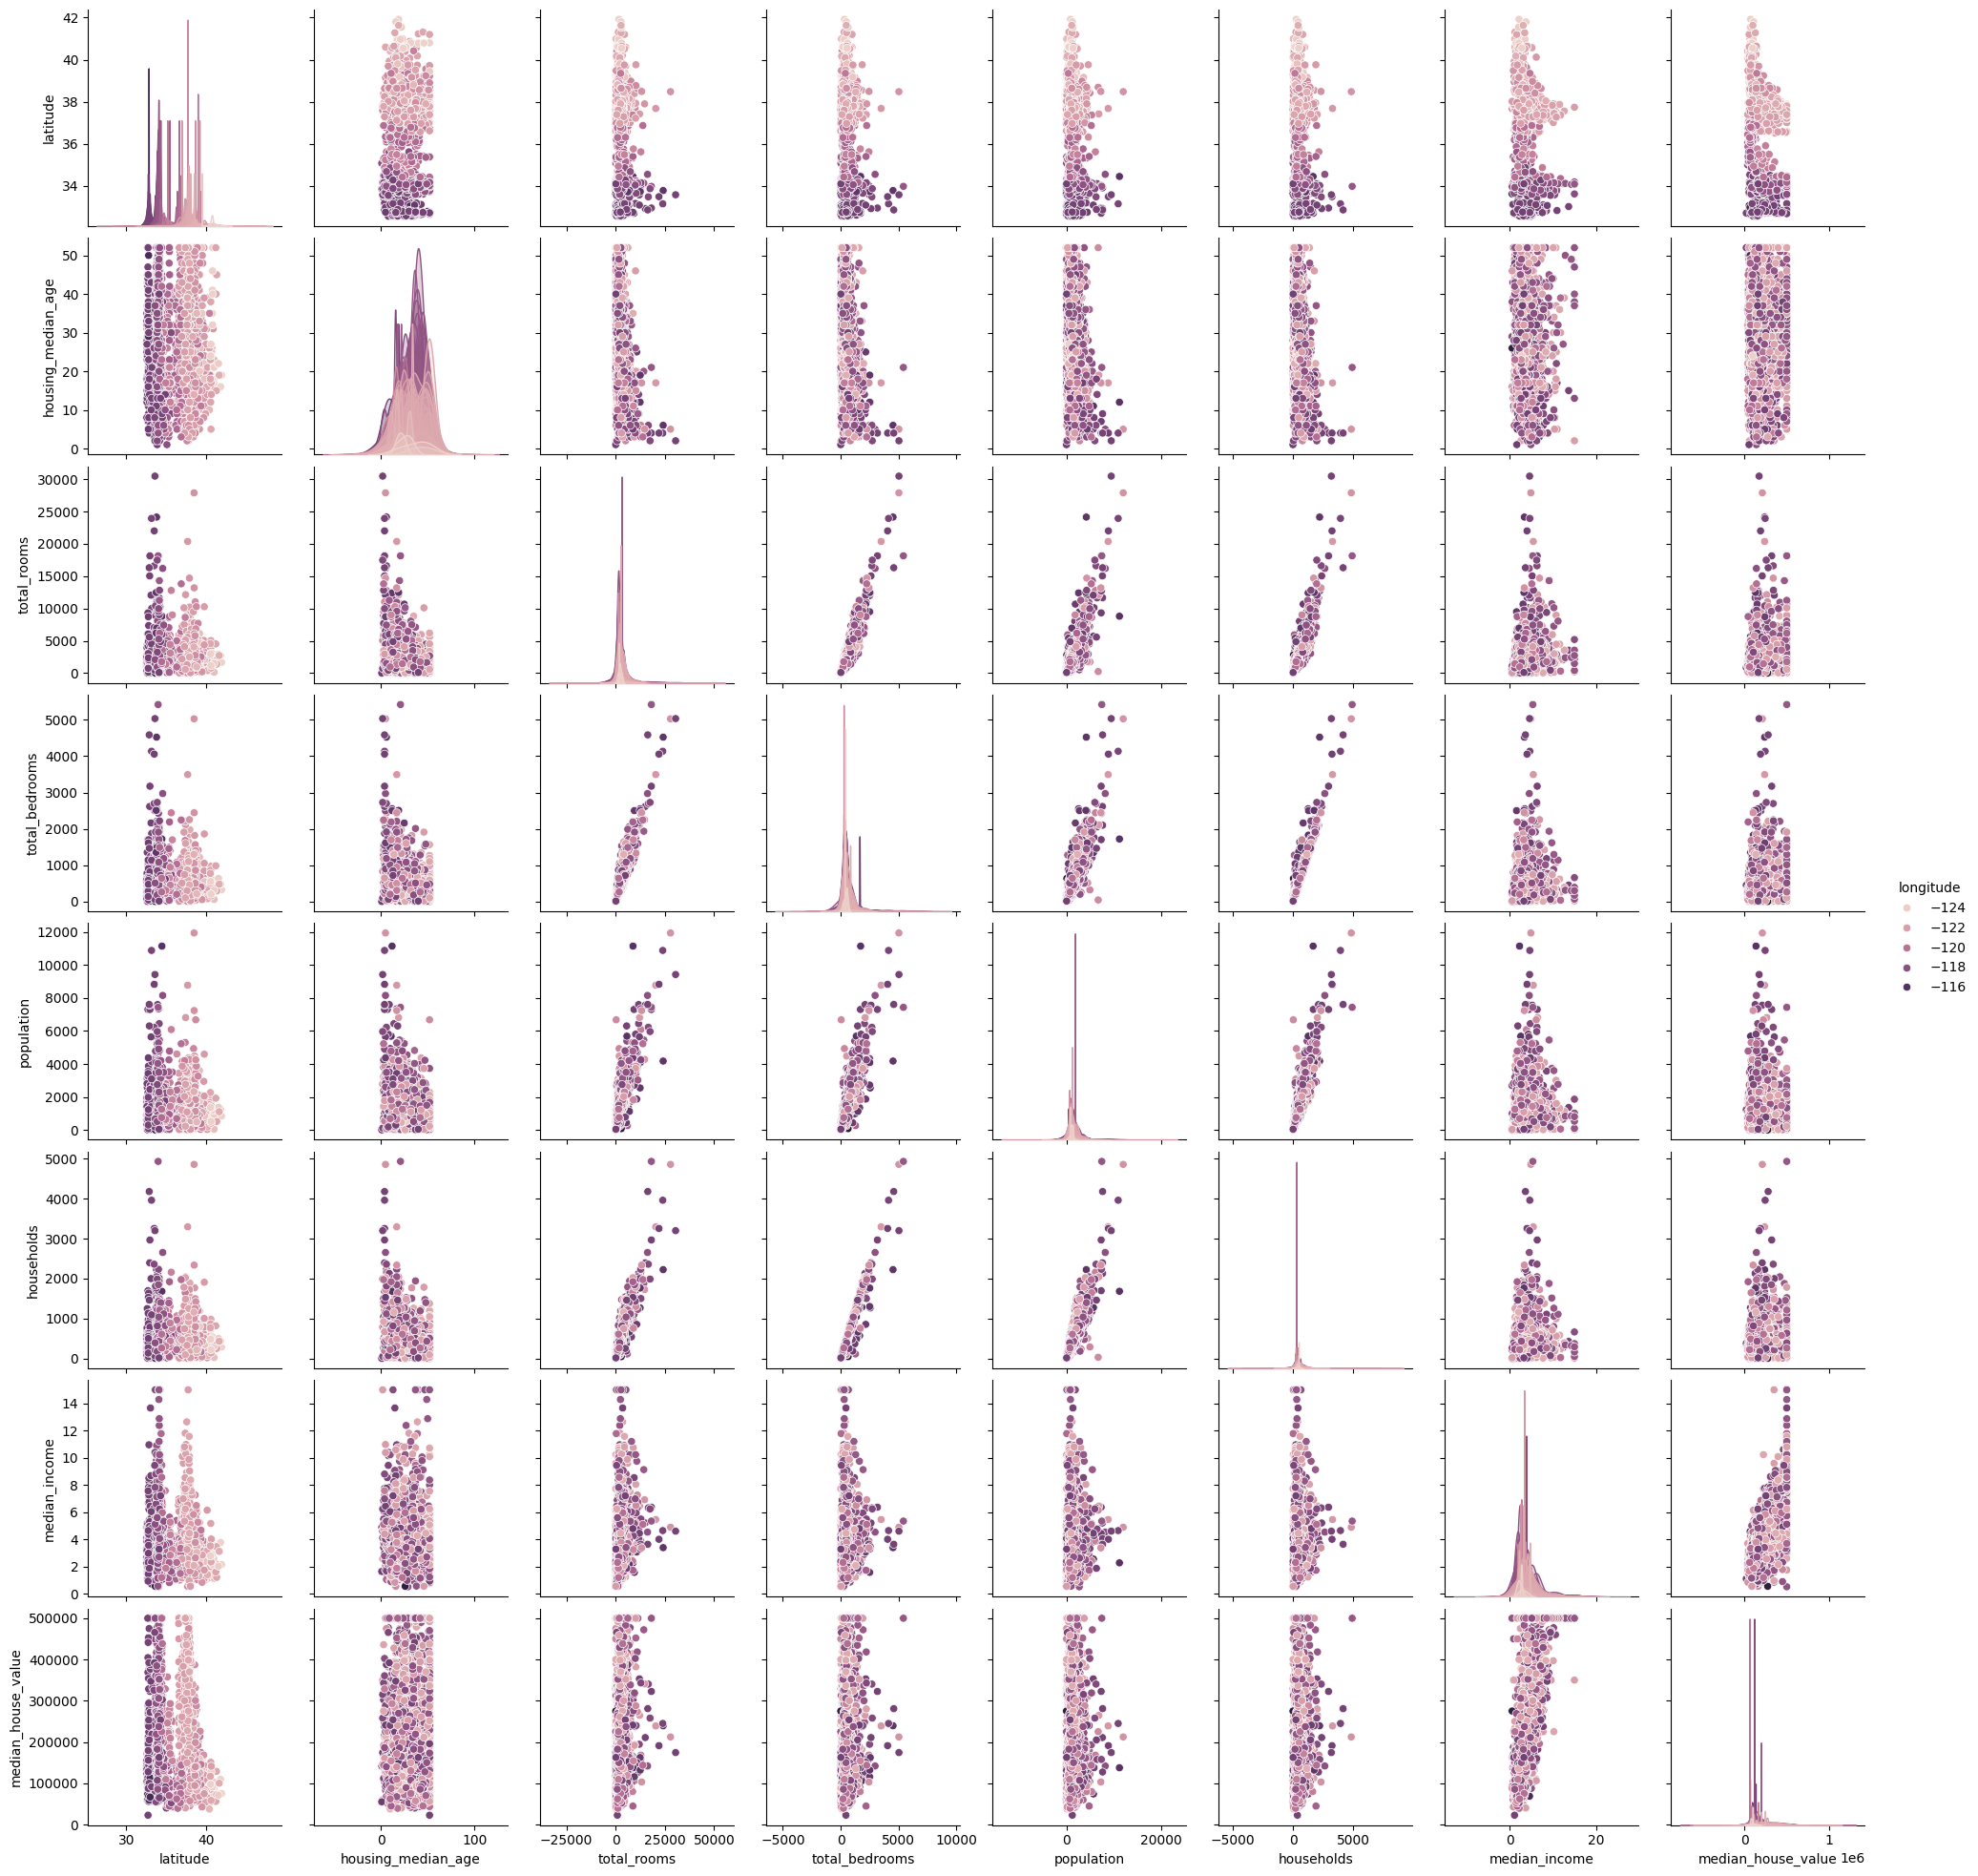

In [ ]:
sns.pairplot(df, hue='longitude')

In [ ]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']


In [ ]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
train_y.value_counts()/train_y.shape[0]

#not useful as this is used for classification not for regression

,count
median_house_value,
500001.0,0.046667
350000.0,0.010000
137500.0,0.007778
162500.0,0.006667
150000.0,0.005556
...,...
129600.0,0.001111
130600.0,0.001111
85400.0,0.001111


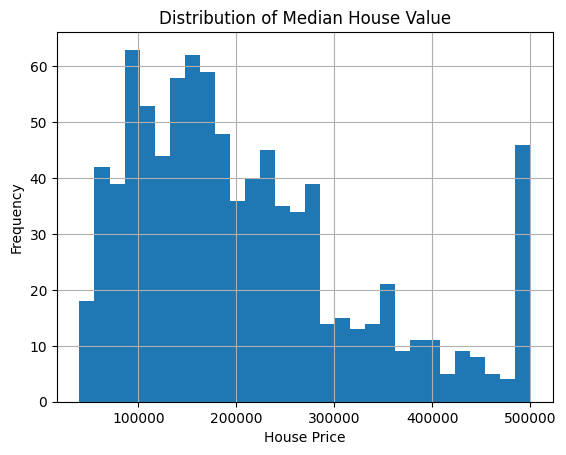

In [ ]:
train_y.hist(bins=30)
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.title("Distribution of Median House Value")
plt.show()

In [ ]:
train_y.describe()


,median_house_value
count,900.000000
mean,209692.602222
std,116844.346829
min,39800.000000
25%,120200.000000
50%,183500.000000
75%,269725.000000
max,500001.000000


In [ ]:
pd.cut(train_y, bins=5).value_counts()

,count
median_house_value,
"(131840.2, 223880.4]",303
"(39339.799, 131840.2]",259
"(223880.4, 315920.6]",182
"(315920.6, 407960.8]",79
"(407960.8, 500001.0]",77


In [ ]:
from sklearn.metrics import mean_squared_error

In [ ]:
model = LinearRegression()
model.fit(train_X,train_y)

y_pred= model.predict(test_X)
#print(y_pred)
print(mean_squared_error(test_y,y_pred))

4586505886.68125


In [ ]:
print(f"Initial X shape: {X.shape}")
print(f"Initial y shape: {y.shape}")

Initial X shape: (3000, 8)
Initial y shape: (3000,)


In [ ]:
print(f"Shape of train_X: {train_X.shape}")
print(f"Shape of train_y: {train_y.shape}")
print(f"Shape of test_X: {test_X.shape}")
print(f"Shape of test_y: {test_y.shape}")

Shape of train_X: (2400, 8)
Shape of train_y: (2400,)
Shape of test_X: (600, 8)
Shape of test_y: (600,)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(train_X, train_y)

y_pred = model.predict(test_X)

from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(test_y, y_pred))
print("RMSE with Random Forest:", rmse)


RMSE with Random Forest: 57576.439782435526


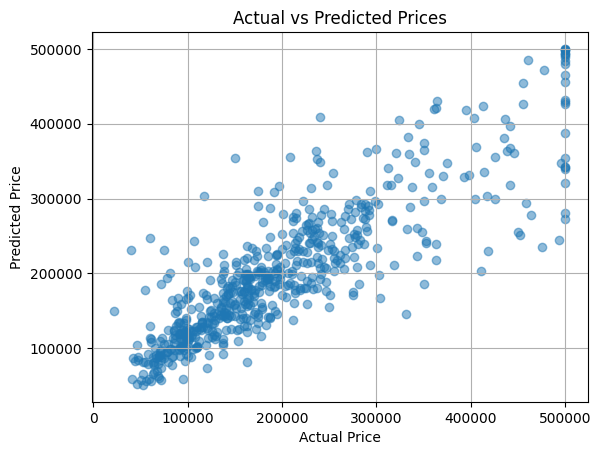

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(test_y, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.grid(True)
plt.show()


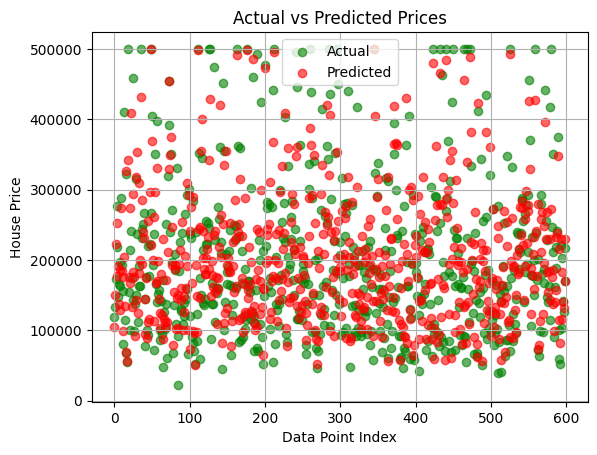

In [ ]:
import matplotlib.pyplot as plt

# Plot actual values
plt.scatter(range(len(test_y)), test_y, color='green', label='Actual', alpha=0.6)

# Plot predicted values
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicted', alpha=0.6)

# Labels and title
plt.xlabel("Data Point Index")
plt.ylabel("House Price")
plt.title("Actual vs Predicted Prices")
plt.legend()
plt.grid(True)
plt.show()


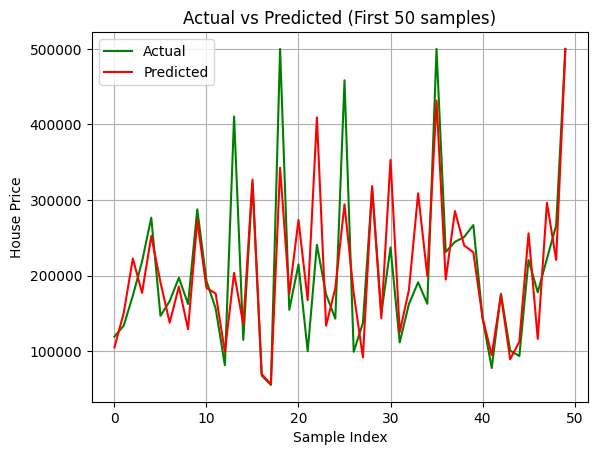

In [ ]:
plt.plot(test_y.values[:50], label='Actual', color='green')
plt.plot(y_pred[:50], label='Predicted', color='red')
plt.xlabel("Sample Index")
plt.ylabel("House Price")
plt.title("Actual vs Predicted (First 50 samples)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4)
model.fit(train_X, train_y)
y_pred = model.predict(test_X)


In [52]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(test_y, y_pred)
print("Mean Squared Error (MSE) with XGBoost:", mse)

rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE) with XGBoost:", rmse)

Mean Squared Error (MSE) with XGBoost: 3283668114.8830986
Root Mean Squared Error (RMSE) with XGBoost: 57303.299336801705
